# 04 — The improved model and honest uncertainty

This is the main system. We take the no-engine baseline from notebook 03 (MAE ≈ 293) and add the
full 77-feature vector (engine move quality + clock + game structure), train LightGBM with early
stopping, and attach a **conformal 90% prediction interval** to every estimate.

**Contents.**
1. The improvement table, with confidence intervals.
2. What the model uses: SHAP and feature-group ablations.
3. Conformalized quantile regression (CQR): turning a raw 87%-coverage interval into a 90% one.
4. Where the interval is too narrow: coverage by rating band, and the band confusion matrix.
5. Several games per player: averaging predictions, and why the average needs recalibrating.

**Splits.** Players (not games) are split into train (54%), validation (16%, early stopping),
calibration (10%, used only by post-hoc steps: the conformal correction and the aggregate
recalibration) and test (20%). No player is in two splits.

> **Reproducibility.** This notebook reads `reports/eval_artifacts.json` and the figures in
> `reports/figures/`, written by `python -m src.evaluate` on the full data (~6 min). The tuned
> row is read from the experiment log `reports/results.md`. Set `RUN_HEAVY = True` to retrain live;
> the pipeline is deterministic (fixed seed), so the numbers match.

In [1]:
# --- Setup: paths, style, and the shared save-and-show helper -------------------------------
import sys, json, warnings
from pathlib import Path

# Make `import src...` work whether the notebook is run from notebooks/ or the repo root.
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.config import load_config
from src.plotting import set_style, save_fig
import math, re

warnings.filterwarnings("ignore")          # keep library chatter out of the rendered notebook
cfg = load_config()
set_style()                                 # one house style for every figure
OUT = cfg["outputs"]                        # every data/report path comes from config.yaml
FIGROOT = Path(cfg["paths"]["figures"])
FIG = FIGROOT / "notebook_04_model"                  # this notebook's figure folder (auto-created)
BANDS = cfg["rating_bands"]

def show(path):
    "Display a figure that save_fig() just wrote to reports/figures/."
    display(Image(filename=str(path)))

RUN_HEAVY = False   # True: retrain the full model live (~6 min) and refresh the artifact + figures
if RUN_HEAVY:
    from src.evaluate import run_evaluation
    run_evaluation(cfg, OUT["features"], OUT["games_clean"], tune=False, make_figures=True,
                   results_md=None, artifacts_path=OUT["eval_artifacts"])

A = json.loads(Path(OUT["eval_artifacts"]).read_text(encoding="utf-8"))
print("artifact from commit:", A["source_commit"], "| test instances:", f"{A['n_test']:,}",
      "| test players:", f"{A['n_test_players']:,}", "| features:", A["n_features"])

def latest_md_section(substr):
    "The newest reports/results.md entry whose heading contains `substr`."
    blocks = re.split(r"(?m)^## ", Path(OUT["results_log"]).read_text(encoding="utf-8"))[1:]
    hits = [b for b in blocks if substr in b.splitlines()[0]]
    return hits[-1] if hits else None

artifact from commit: 33171ec | test instances: 120,513 | test players: 50,357 | features: 77


## 1. The improvement table

The full feature set turns a weak surface model into a useful one. The tuned row is the best
Optuna configuration (25 trials, 3-fold cross-validation grouped by player *inside the training
split*, so the test set is never used for tuning); its hyperparameters are logged with the run.

,MAE,RMSE
stage,,
no-engine baseline,293.4,NaN
+ all 77 features,239.1,300.1
+ Optuna tuned,237.2,297.6


full-feature gain: 54.2 Elo  (95% CI 52.7 .. 55.8, player-clustered bootstrap)
tuning gain      : 2.0 Elo  (95% CI 1.8 .. 2.2)
tuned best_params: {'num_leaves': 211, 'learning_rate': 0.010060300707949244, 'feature_fraction': 0.5019379341956828, 'bagging_fraction': 0.8531334621899735, 'bagging_freq': 1, 'min_child_samples': 89, 'reg_lambda': 2.7159108131066168}


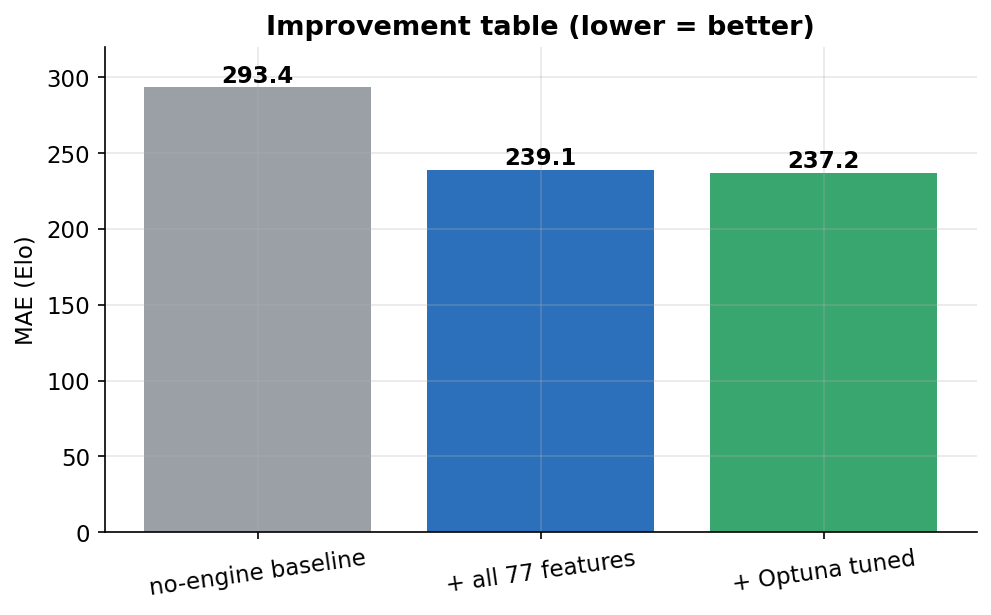

In [2]:
tuned_block = latest_md_section("improved model (tuned")
tuned_mae = float(re.search(r"\+ tuned \| ([\d.]+)", tuned_block).group(1))
tuned_rmse = float(re.search(r"\+ tuned \| [\d.]+ \| ([\d.]+)", tuned_block).group(1))
best_params = re.search(r"best_params: `(.+)`", tuned_block).group(1)
tuned_ci = re.search(r"full - tuned ([+-][\d.]+) \[95% CI ([+-][\d.]+), ([+-][\d.]+)\]", tuned_block)

imp = pd.DataFrame([
    ("no-engine baseline", round(A["baseline_mae"], 1), float("nan")),
    ("+ all 77 features",   round(A["full_mae"], 1),     round(A["full_rmse"], 1)),
    ("+ Optuna tuned",      round(tuned_mae, 1),          round(tuned_rmse, 1)),
], columns=["stage", "MAE", "RMSE"]).set_index("stage")
display(imp)

b = A["bootstrap"]["baseline - full"]
print(f"full-feature gain: {b['diff']:.1f} Elo  (95% CI {b['lo']:.1f} .. {b['hi']:.1f}, player-clustered bootstrap)")
if tuned_ci:
    print(f"tuning gain      : {float(tuned_ci.group(1)):.1f} Elo  (95% CI {float(tuned_ci.group(2)):.1f} .. {float(tuned_ci.group(3)):.1f})")
print("tuned best_params:", best_params)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(imp.index, imp["MAE"], color=["#9aa0a6", "#2c6fbb", "#3aa66f"])
for bar, v in zip(bars, imp["MAE"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.1f}", ha="center", va="bottom", fontweight="bold")
ax.set(ylabel="MAE (Elo)", title="Improvement table (lower = better)", ylim=(0, 320))
ax.tick_params(axis="x", rotation=8)
show(save_fig(fig, "improved_improvement_table", FIG))

**Reading it.** The full feature set (move quality, clock and game-structure features such as
phase lengths and presence flags) cuts MAE by about **54 Elo (~18%)** over the no-engine baseline,
with a tight confidence interval — the biggest single step in the project. Tuning adds
about 2 Elo more: the features, not the hyperparameters, do the work. We report the untuned model
as the headline (it is what every analysis below uses) and the tuned one as the best achieved.

*How the CIs are computed:* the test set is resampled **by player** (all of a player's games move
together), 1,000 times, and the MAE difference is recomputed on the same resample for both models.
Resampling games instead of players would understate the uncertainty, because a player's games are
not independent. The models are held fixed, so the CIs reflect test-set sampling, not
training-run variability.

In [3]:
p, pp = A["point"], A["per_player"]
metrics = pd.DataFrame({
    "value": [round(p["mae"], 1), round(p["rmse"], 1), round(p["median_ae"], 0), round(p["r2"], 3),
              round(p["spearman"], 3), f"{p['within_100']:.0%}", f"{p['within_200']:.0%}",
              f"{p['bias']:+.1f}", round(pp["mae"], 1), f"{pp['n_players']:,}"],
}, index=["MAE", "RMSE", "median absolute error", "R^2", "Spearman rho", "within 100 Elo", "within 200 Elo",
          "bias (mean pred - actual)", "per-player MAE (all their test games averaged)", "test players"])
display(metrics)

,value
MAE,239.1
RMSE,300.1
median absolute error,202.0
R^2,0.545
Spearman rho,0.726
within 100 Elo,26%
within 200 Elo,50%
bias (mean pred - actual),-3.4
per-player MAE (all their test games averaged),218.2
test players,"50,357"


**Reading it.** On a *single* game the model explains R² ≈ 0.55 of the rating variance, ranks
players with ρ ≈ 0.73, is within 200 Elo about half the time, and is essentially unbiased overall
(−3 Elo). The median absolute error (≈ 202) is below the MAE (≈ 239) by about the ratio expected
for roughly normal errors; the errors are largest at the rating extremes (notebook 05). Averaging
all of a player's test games gives 218 per player, against about 235 for one random game per
player (the per-player version of the single-game error, §5); §5 shows how to do better.

## 2. What the model uses — SHAP and ablations

SHAP attributes each prediction to features (global importance and direction). A **group
ablation** drops a whole feature family, retrains, and measures the MAE lost.

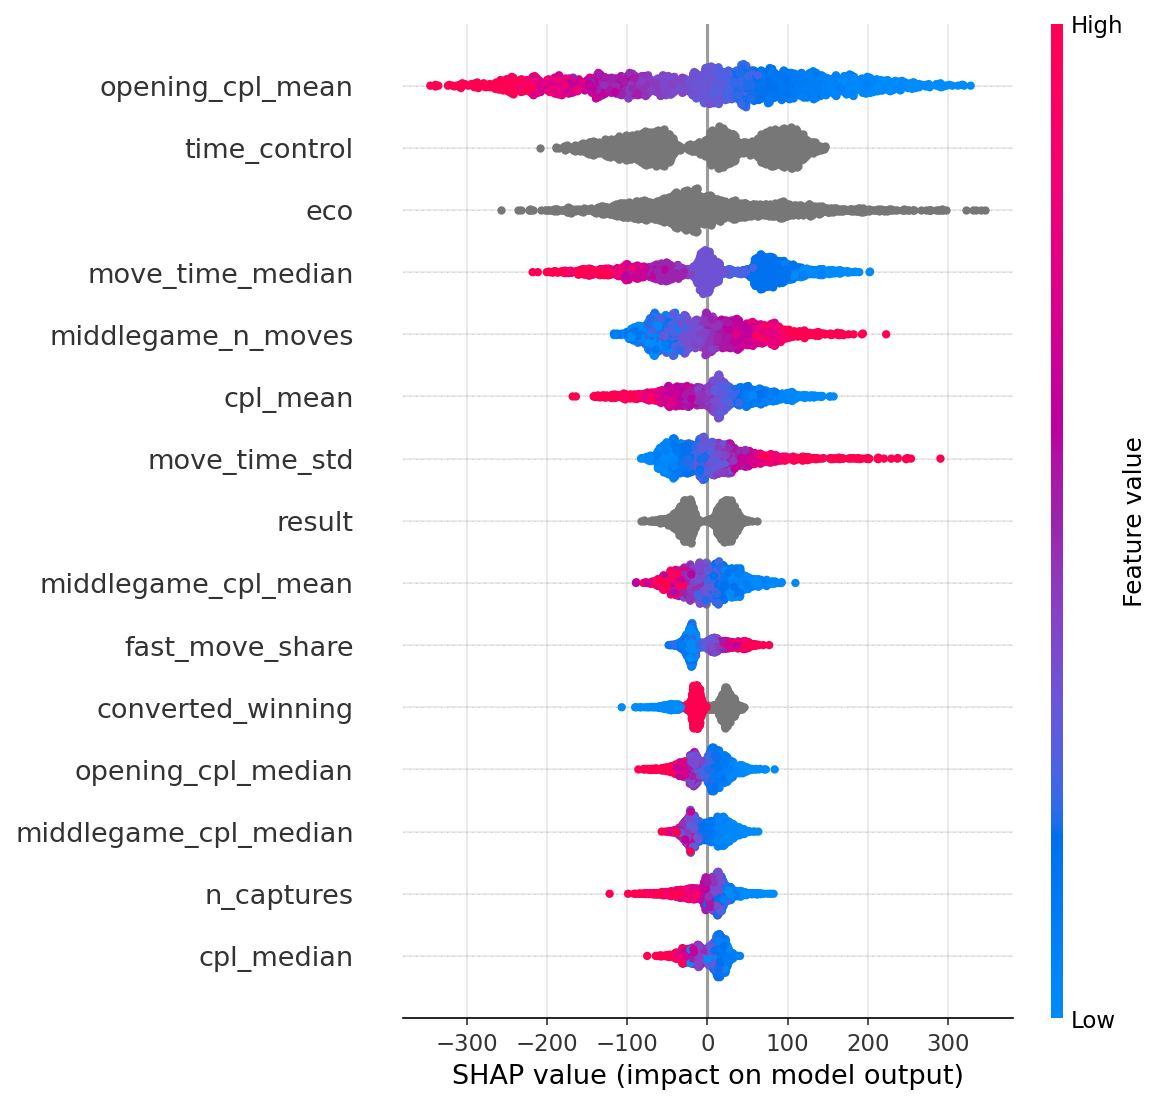

In [4]:
show(FIGROOT / "shap_summary.png")        # written by src.evaluate (2,000 test rows)

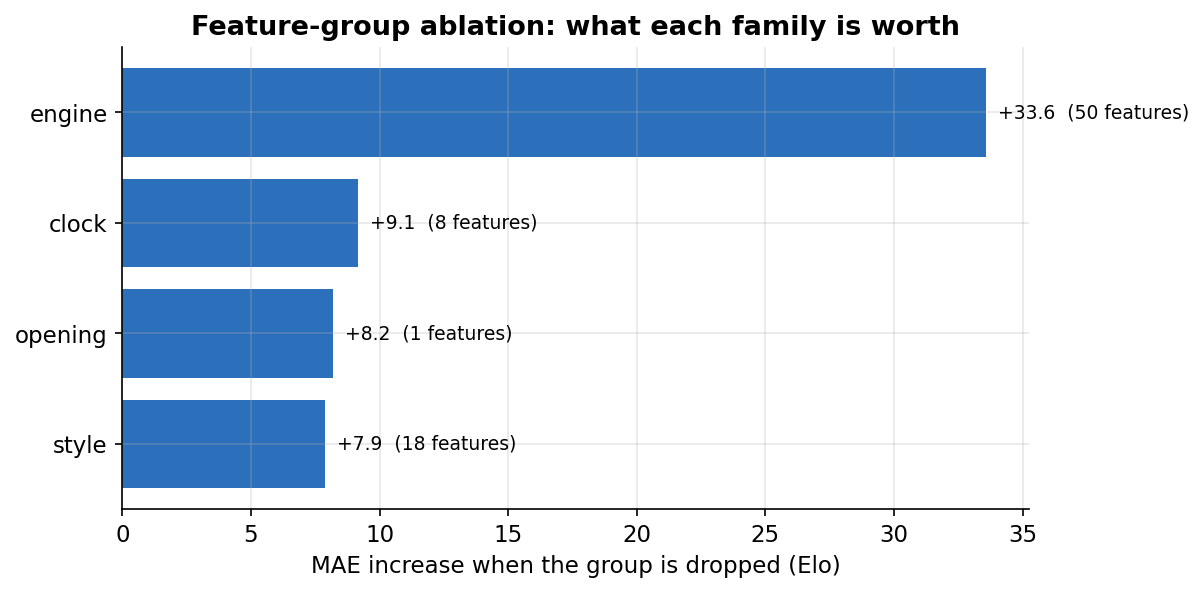

,group,n_dropped,mae_without,mae_increase,95% CI
0,engine,50,272.7,33.6,32.5 .. 34.6
1,clock,8,248.3,9.1,8.5 .. 9.8
2,opening,1,247.3,8.2,7.6 .. 8.8
3,style,18,247.0,7.9,7.4 .. 8.4


In [5]:
ab = pd.DataFrame(A["ablations"]).sort_values("mae_increase", ascending=False)
ab["95% CI"] = [f"{A['bootstrap'][f'no_{g} - full']['lo']:.1f} .. {A['bootstrap'][f'no_{g} - full']['hi']:.1f}"
                for g in ab["group"]]
fig, ax = plt.subplots(figsize=(7.8, 4))
bars = ax.barh(ab["group"], ab["mae_increase"], color="#2c6fbb")
for bar, v, n in zip(bars, ab["mae_increase"], ab["n_dropped"]):
    ax.text(v, bar.get_y() + bar.get_height() / 2, f"  +{v:.1f}  ({n} features)", va="center", fontsize=9)
ax.invert_yaxis()
ax.set(xlabel="MAE increase when the group is dropped (Elo)", title="Feature-group ablation: what each family is worth")
show(save_fig(fig, "improved_ablation", FIG))
display(ab[["group", "n_dropped", "mae_without", "mae_increase", "95% CI"]].round(1).reset_index(drop=True))

**Reading it.** The two views agree on the main point and differ in detail.

- **SHAP** (per feature): the single most influential feature is `opening_cpl_mean` — how much the
  player lost in the first 15 moves — followed by `time_control`, the opening code `eco`,
  `move_time_median` and `middlegame_n_moves`; overall `cpl_mean` comes next. Time control and
  opening choice are legitimate context (players of different strength favour different time
  controls and openings); none of them uses the opponent's rating or identity.
- **Ablation** (per family): dropping the whole **engine** group costs about **+34 MAE** — more than
  the other three groups combined. **Clock** (+9), **opening** (`eco`, +8) and **style** (+8) each
  add a smaller but clearly non-zero amount (every CI excludes 0).

Why the difference: SHAP splits credit among correlated features, so a family of ~50 overlapping
move-quality features shows up as many medium bars, while one-feature columns like `time_control`
get all their credit on one bar. The ablation measures what a family is worth as a whole. The
groups are disjoint but their information is correlated, so the losses are not additive (they sum
to about 59, more than the 54-Elo total gain). The order
matches notebook 01: how well you play separates ratings most.

## 3. Honest uncertainty: conformalized quantile regression (CQR)

A point estimate that is off by ~239 on average needs an honest *range*. Three LightGBM quantile
models (0.05 / 0.50 / 0.95) give a raw 90% interval, but quantile regression is not guaranteed to be
calibrated. **Split conformal prediction** (Lei et al. 2018) applied to quantile regression
(**CQR**, Romano, Patterson & Candès 2019) corrects it using held-out data:

- Hold out a **calibration** split that no model is fit on.
- For each calibration point compute the score `E = max(lower − y, y − upper)` (how far outside
  the interval it fell; negative if inside).
- Take the `k`-th smallest score, `k = ⌈(n+1)(1−α)⌉`, and widen (or narrow) the interval by it.

If calibration and test points are exchangeable, the corrected interval covers at least 90% on
average over calibration draws. Here the points are games, and a player contributes several games
that are not independent, so the finite-sample guarantee does not formally apply to rows: what we
report on the test players is **empirical** coverage. A second check keeps **one random game per
player** in both calibration and test; the scores are then independent across players, and the
guarantee applies to "a random game of a new player".

In [6]:
# The conformal quantile with the actual src functions, on a small illustrative calibration set.
from src.model import _conformal_quantile, conformal_correction

rng = np.random.RandomState(0)
y_cal = rng.normal(1600, 300, 400)
med = y_cal + rng.normal(0, 150, 400)
cal = {"lower": med - 250, "median": med, "upper": med + 250}   # a too-narrow raw 90% interval
alpha = 0.10
E = np.maximum(cal["lower"] - y_cal, y_cal - cal["upper"])
k = math.ceil((len(E) + 1) * (1 - alpha))
lo, hi = conformal_correction(cal, y_cal, alpha)
print(f"illustration: n={len(E)}, k=ceil((n+1)*0.9)={k}, correction = {k}-th smallest score = {_conformal_quantile(E, 1 - alpha):+.1f} Elo")

# The real effect on the test set, next to the interval you get without looking at the game.
pi = A["prior_interval"]
cov = pd.DataFrame({
    "coverage %": [pi["coverage"] * 100, A["coverage_raw"] * 100, A["coverage_cqr_plain"] * 100, A["coverage_cqr_mondrian"] * 100],
    "mean width (Elo)": [pi["width"], A["mean_interval_width_raw"], A["mean_interval_width_plain"], A["mean_interval_width_mondrian"]],
}, index=["no game: 5%-95% of training ratings", "raw quantile models", "+ split CQR (plain)", "+ Mondrian CQR"]).round(1)
display(cov)
print(f"plain CQR correction: +{A['conformal_correction'][0]:.1f} Elo on each side; "
      f"interval is {1 - A['mean_interval_width_plain'] / pi['width']:.0%} narrower than the no-game interval")
og = A["cqr_one_game_per_player"]
print(f"one game per player ({og['n_calib_players']:,} calibration / {og['n_test_players']:,} test players, "
      f"{og['draws']} random draws): coverage {og['coverage']:.1%} "
      f"(range {og['coverage_min']:.1%}-{og['coverage_max']:.1%}), width {og['mean_width']:.0f}")

illustration: n=400, k=ceil((n+1)*0.9)=361, correction = 361-th smallest score = +7.9 Elo


,coverage %,mean width (Elo)
no game: 5%-95% of training ratings,90.1,1465.0
raw quantile models,87.4,944.9
+ split CQR (plain),89.8,999.0
+ Mondrian CQR,89.9,1001.3


plain CQR correction: +27.1 Elo on each side; interval is 32% narrower than the no-game interval
one game per player (24,172 calibration / 50,357 test players, 20 random draws): coverage 90.1% (range 89.9%-90.2%), width 983


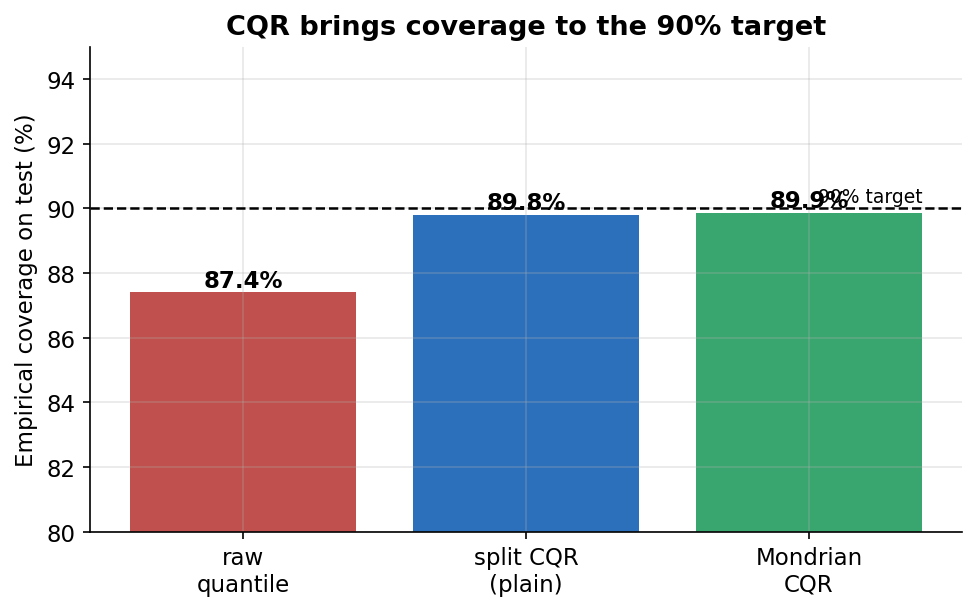

In [7]:
labels = ["raw\nquantile", "split CQR\n(plain)", "Mondrian\nCQR"]
vals = [A["coverage_raw"] * 100, A["coverage_cqr_plain"] * 100, A["coverage_cqr_mondrian"] * 100]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(labels, vals, color=["#c0504d", "#2c6fbb", "#3aa66f"])
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.1f}%", ha="center", va="bottom", fontweight="bold")
ax.axhline(90, color="k", ls="--", lw=1.2); ax.text(2.4, 90.2, "90% target", fontsize=9, ha="right")
ax.set(ylabel="Empirical coverage on test (%)", title="CQR brings coverage to the 90% target", ylim=(80, 95))
show(save_fig(fig, "improved_cqr_coverage", FIG))

**Reading it.** The raw quantile interval covers only about 87% — it overstates its own confidence.
Split CQR widens each side by about 27 Elo and brings test coverage to **89.8%** (90% target;
with 120k test games the sampling error is a few tenths of a percent). **Mondrian CQR** (a separate
correction per *predicted* rating band) gives 89.9% at about the same width. With **one game per
player**, the setting in which the guarantee holds, coverage is **90.1%** (89.9–90.2% over 20 random
draws): the dependence between a player's games does not distort the average coverage here.

**How useful is the interval?** Its mean width is about **1,000 Elo** (±500). That is wide — one
blitz game is weak evidence — but it is about **32% narrower** than the 1,465-Elo interval you
would give *without* looking at the game (the 5–95% range of all ratings), at the same 90%
coverage. The model narrows the plausible range by a third, and says so honestly.

## 4. Where the interval is too narrow: coverage by band, and the confusion matrix

Marginal coverage is an average over all players. By rating band, it is not uniform.

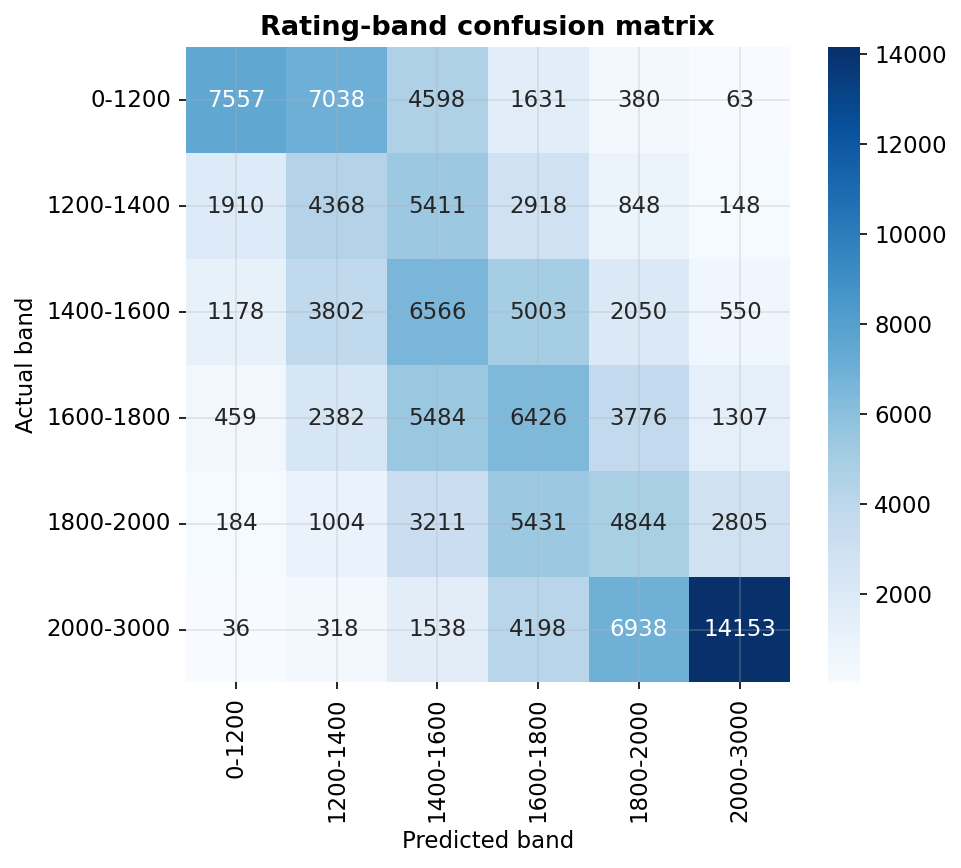

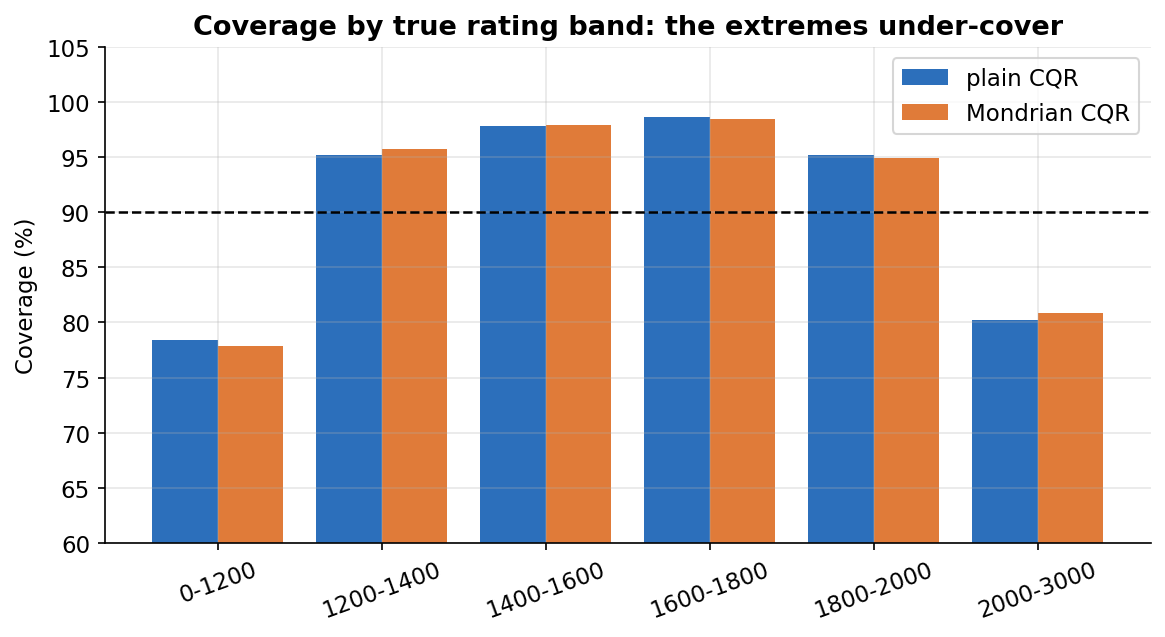

,band,n,plain,mondrian,share of test
0,0-1200,21267,78.4,77.8,17.6
1,1200-1400,15603,95.2,95.7,12.9
2,1400-1600,19149,97.8,97.9,15.9
3,1600-1800,19834,98.6,98.4,16.5
4,1800-2000,17479,95.1,94.9,14.5
5,2000-3000,27181,80.2,80.9,22.6


band accuracy: 36.4% exact, 75.9% within one band


In [8]:
show(FIGROOT / "band_confusion.png")       # point-prediction bands (written by src.evaluate)

pb = pd.DataFrame(A["coverage_by_band_plain"])[["band", "n", "coverage"]].rename(columns={"coverage": "plain"})
mb = pd.DataFrame(A["coverage_by_band_mondrian"])[["band", "coverage"]].rename(columns={"coverage": "mondrian"})
cov_band = pb.merge(mb, on="band")
cov_band["share of test"] = cov_band["n"] / cov_band["n"].sum()
x = np.arange(len(cov_band))
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(x - 0.2, cov_band["plain"] * 100, width=0.4, label="plain CQR", color="#2c6fbb")
ax.bar(x + 0.2, cov_band["mondrian"] * 100, width=0.4, label="Mondrian CQR", color="#e07b39")
ax.axhline(90, color="k", ls="--", lw=1.2)
ax.set_xticks(x); ax.set_xticklabels(cov_band["band"], rotation=20)
ax.set(ylabel="Coverage (%)", title="Coverage by true rating band: the extremes under-cover", ylim=(60, 105))
ax.legend()
show(save_fig(fig, "improved_coverage_by_band", FIG))
display(cov_band.assign(plain=lambda t: (t.plain * 100).round(1), mondrian=lambda t: (t.mondrian * 100).round(1),
                        **{"share of test": lambda t: (t["share of test"] * 100).round(1)}))
print(f"band accuracy: {A['band_exact']:.1%} exact, {A['band_adjacent']:.1%} within one band")

**Reading it.** Coverage is 95–99% in the four middle bands but only about **78% below 1200 and
80% at 2000+** (plain CQR; Mondrian gives 78% / 81%) — and those two bands hold about 40% of the
test games (about 35% of the test players). Mondrian CQR does not change
this (notebook 05 explains why). The confusion matrix shows the same pattern for the point
estimate: predictions concentrate near the diagonal in the middle and are pulled toward the centre
at the extremes (about 36% exact band, about 76% within one band). The 90% promise is kept *on
average*, not for every kind of player.

## 5. Several games per player

Most players in the test set have one game, but many have several. The obvious way to use them
is to **average the per-game predictions**. The pipeline's first version of this (below, left) is
confounded: each K is measured on a different set of players (those with at least K games).

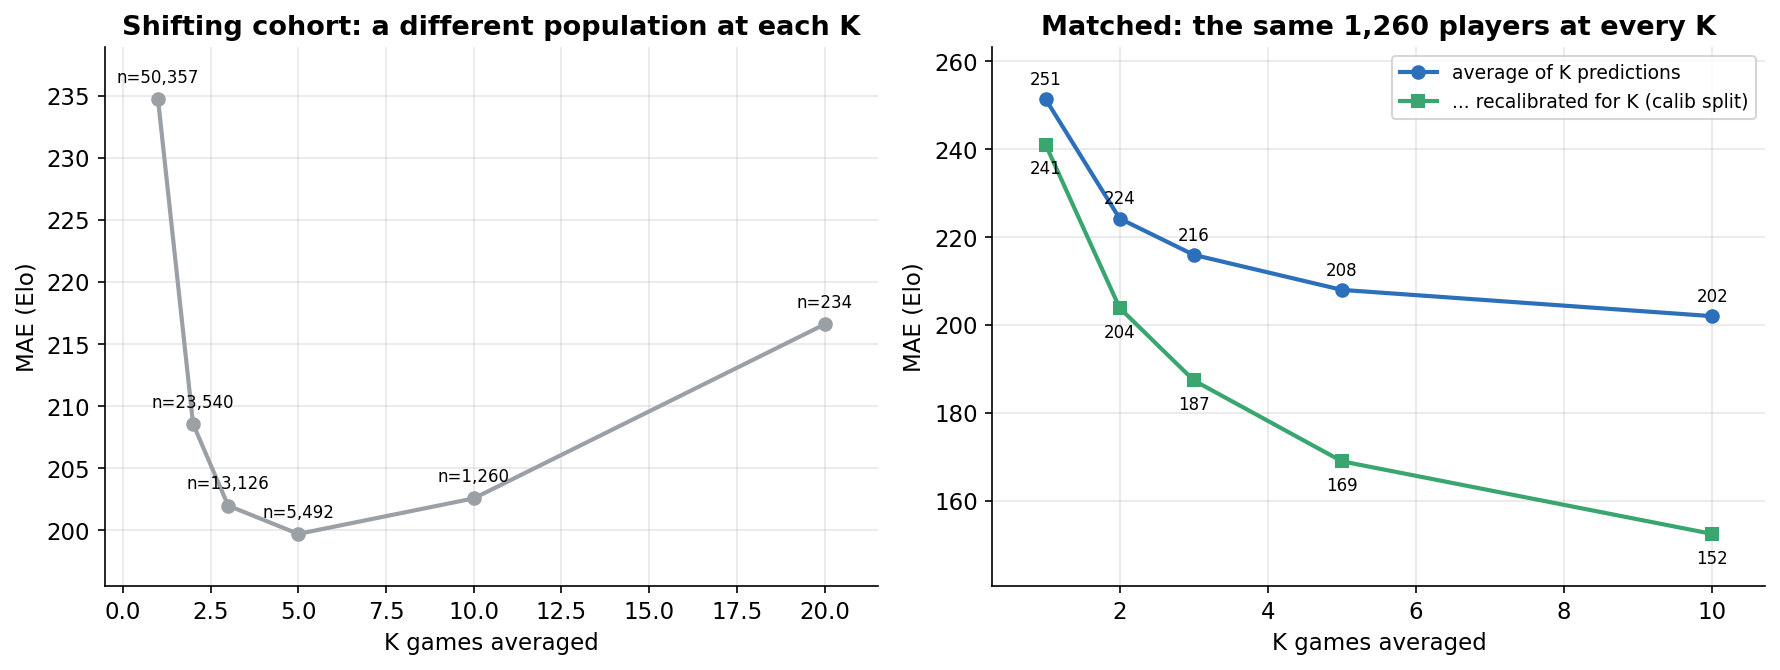

,k,naive_mae,recal_mae,naive_rmse,recal_rmse,slope,intercept
0,1,251.39,241.03,316.18,304.55,0.99,84.65
1,2,224.21,203.86,278.58,257.85,1.19,-257.68
2,3,215.95,187.38,266.90,237.44,1.27,-407.96
3,5,207.97,168.95,255.31,214.21,1.35,-543.72
4,10,201.99,152.42,246.93,194.46,1.41,-654.42


In [9]:
curve = pd.DataFrame(A["aggregation_curve"])
matched = pd.DataFrame(A["matched_aggregation"])
n_matched = int(matched["n_players"].iloc[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))
ax1.plot(curve["k"], curve["mae"], "-o", color="#9aa0a6", ms=6, lw=2)
for _, row in curve.iterrows():
    ax1.annotate(f"n={int(row['n_players']):,}", (row["k"], row["mae"]), textcoords="offset points",
                 xytext=(0, 8), ha="center", fontsize=8)
ax1.set(xlabel="K games averaged", ylabel="MAE (Elo)", title="Shifting cohort: a different population at each K")

ax2.plot(matched["k"], matched["naive_mae"], "-o", color="#2c6fbb", lw=2, label="average of K predictions")
ax2.plot(matched["k"], matched["recal_mae"], "-s", color="#3aa66f", lw=2, label="... recalibrated for K (calib split)")
for _, row in matched.iterrows():
    ax2.annotate(f"{row['naive_mae']:.0f}", (row["k"], row["naive_mae"]), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
    ax2.annotate(f"{row['recal_mae']:.0f}", (row["k"], row["recal_mae"]), textcoords="offset points", xytext=(0, -14), ha="center", fontsize=8)
ax2.set(xlabel="K games averaged", ylabel="MAE (Elo)", title=f"Matched: the same {n_matched:,} players at every K")
ax2.legend(fontsize=9)
ax1.margins(x=0.08, y=0.12); ax2.margins(x=0.08, y=0.12)   # keep the point labels inside the axes
fig.tight_layout()
show(save_fig(fig, "improved_aggregation_curve", FIG))
display(matched[["k", "naive_mae", "recal_mae", "naive_rmse", "recal_rmse", "slope", "intercept"]].round(2))

**Reading it.** On the left, the curve even rises after K = 5 — but each point is a different,
shrinking population (50k players at K = 1, a few hundred at K = 20). The right panel fixes the
population: the test players with at least 10 games, measured at every K on random K-game subsets.

- **Averaging helps**, but less than expected: from about 251 at K = 1 to about 202 at K = 10.
  Independent noise alone would shrink much faster.
- **One main reason is shrinkage.** Each single-game prediction is pulled toward the average rating —
  the right hedge for *one* noisy game (notebook 05: the slope of true on predicted is about 0.96,
  so a single game shows no leftover shrinkage). Averaging K such predictions keeps the one-game hedge even
  though K games carry more evidence, so the average stays too close to the centre. The fitted slope
  of true rating on the averaged prediction grows with K (≈ 1.0 at K = 1 to ≈ 1.4 at K = 10).
- **The fix is a K-aware recalibration**: for each K, fit `rating ≈ a_K + b_K · (mean of K
  predictions)` on the *calibration* players (never used for training or testing), and apply it to
  the test players. At K = 10 this brings MAE from about 202 to about **152**. At K = 1 the
  recalibration only re-centres this particular group of very active players (≈ 10 Elo); the extra
  gain at larger K comes from undoing the excess shrinkage.

**What exactly is measured.** The label of each game is the player's rating *at that game*, so
the K-game error is measured against the player's **average recorded rating over those K games**.
Within these five days ratings move little (median within-player standard deviation about 16 Elo
for players with 10+ games), so this is close to "the player's current rating". The population is
the most active players: at least 10 analysed games in five days.

This is the second improvement of the project: when several games of a player are available, the
combined estimate must account for how much evidence it rests on. It is a trade-off rather than a
free gain — stretching the estimates makes mid-rated players worse (about +30 MAE in the two central
bands at K = 5) and extreme-rated players much better (−73 to −93); notebook 05 shows it band by
band. Even recalibrated, K = 10 games leave an MAE of about 152, so shrinkage is not the only source
of error.

In [10]:
k5 = A["aggregate_bands_k5"]
ci = k5["naive_minus_recal_ci"]
print(f"players with >= 5 test games: {k5['n_players']:,} (recalibration fit on {k5['n_calib_players']:,} calibration players)")
print(f"MAE: one game {k5['single_mae']:.1f} -> average of 5 {k5['naive_mae']:.1f} -> recalibrated {k5['recal_mae']:.1f}")
print(f"recalibration gain: {ci['diff']:.1f} Elo (95% CI {ci['lo']:.1f} .. {ci['hi']:.1f}); slope {k5['slope']:.2f}")

players with >= 5 test games: 5,492 (recalibration fit on 2,729 calibration players)
MAE: one game 244.3 -> average of 5 199.6 -> recalibrated 175.1
recalibration gain: 24.4 Elo (95% CI 22.2 .. 26.8); slope 1.35


## Takeaways

- **The full feature set is the main gain:** 293 → 239 MAE (−54, 95% CI 52.7–55.8); removing the
  50 move-quality features costs 34. Tuning adds about 2 more (CI 1.8–2.2).
- **The interval has ≈ 90% empirical coverage on average:** CQR turns an 87%-coverage raw interval into 89.8%
  (90.1% with one game per player, where the conformal guarantee applies),
  and the interval is a third narrower than knowing nothing about the game.
- **But not for every player:** coverage is about 78% / 80% in the two extreme bands (40% of test games).
- **Several games help, if combined correctly:** averaging predictions keeps the one-game shrinkage;
  a K-aware recalibration fit on held-out players removes much of it (K = 10: 202 → 152 MAE), at a
  cost of about +30 MAE in the central bands for −73 to −93 at the extremes (K = 5).

**Next:** notebook 05 asks whether the extreme-band error can be fixed at the single-game level,
and what more games do to it.